29-7-26

In [1]:
#Machine learning
#importing the required libraries
import pandas as pd
from sklearn.linear_model import LinearRegression
data={
    "Hours":[1,2,3,4,5],
    "Marks":[20,40,60,80,100]
}
df=pd.DataFrame(data)
print(df)
x=df[['Hours']]
y=df['Marks']
model=LinearRegression()
model.fit(x,y)
prediction=model.predict([[8]])
print(prediction)


   Hours  Marks
0      1     20
1      2     40
2      3     60
3      4     80
4      5    100
[160.]


c:\Users\esair\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


30-7-26

In [2]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)


[40.]


In [3]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,y_pred)
print("MAE:",mae)

MAE: 1.4210854715202004e-14


In [4]:
from sklearn.linear_model  import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
df=pd.read_csv(r"C:\Users\esair\Downloads\retail_sales_dataset.csv")


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [6]:
df_numerical=df.select_dtypes(include=['number']).columns
df_numerical.tolist()

['Transaction ID', 'Age', 'Quantity', 'Price per Unit', 'Total Amount']

In [7]:
df_category=df.select_dtypes(include=['object','string']).columns
df_category.to_list()

['Date', 'Customer ID', 'Gender', 'Product Category']

In [8]:
x=df[['Total Amount','Quantity','Price per Unit','Transaction ID']]
y=df['Age']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
# print(y_pred)
mae=mean_squared_error(y_test,y_pred)
print("MSE:",mae)

MSE: 193.5571790817599


In [9]:
from sklearn.metrics import root_mean_squared_error
model=LinearRegression()
model.fit(x_train,y_train)
y_predict=model.predict(x_test)
RMSE=root_mean_squared_error(y_test,y_pred)
print(RMSE)

13.912482851085922


In [10]:
cols = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
df=pd.read_csv(r"C:\Users\esair\OneDrive\Desktop\thelast\magic04.data",names=cols)
df.head()



,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [11]:
df["class"]=(df["class"]=="g").astype(int)

In [12]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


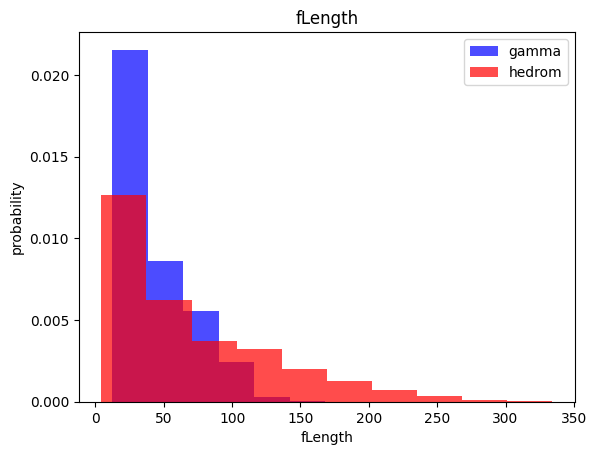

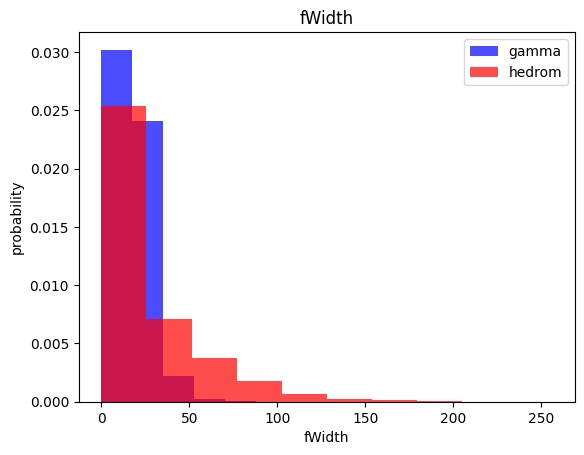

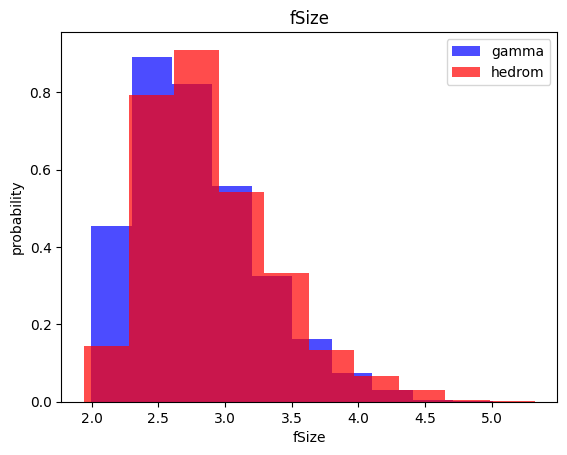

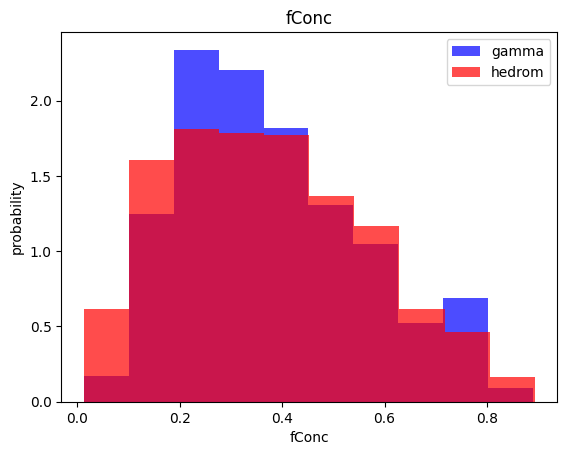

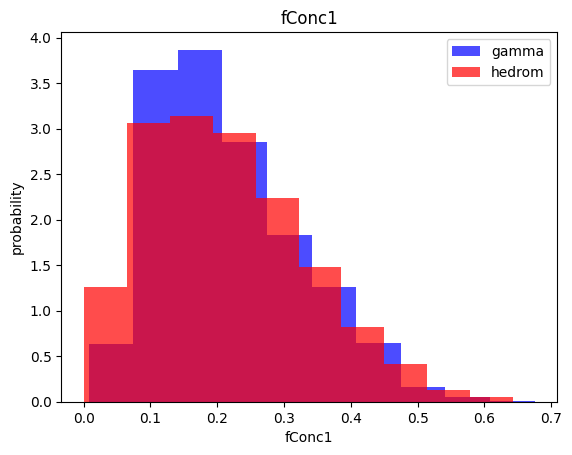

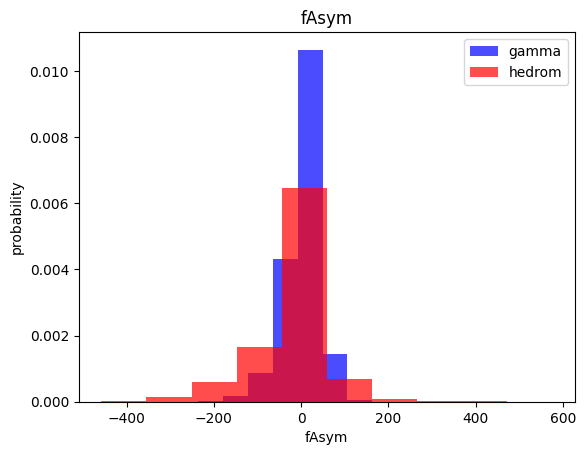

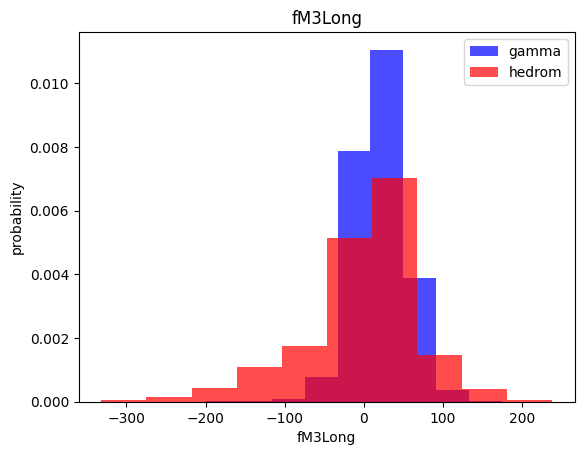

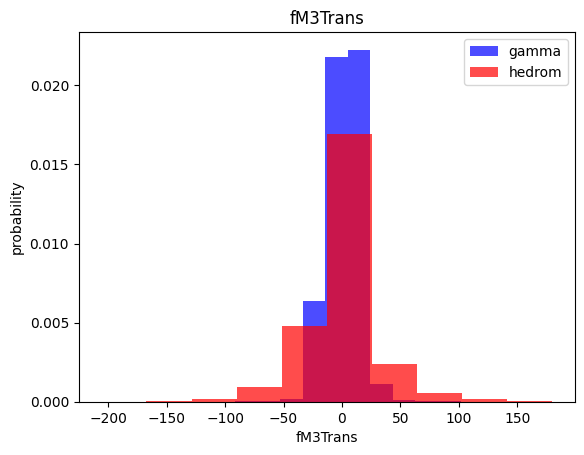

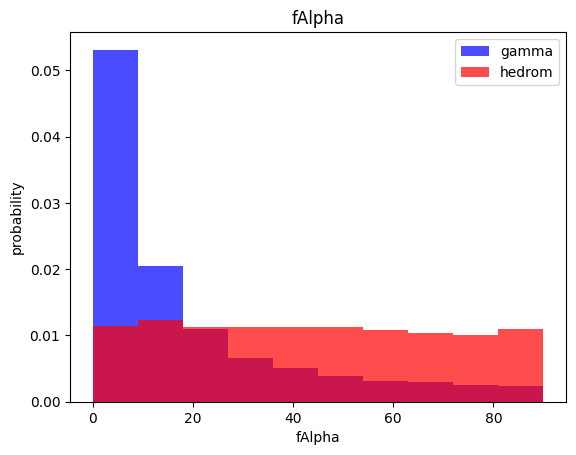

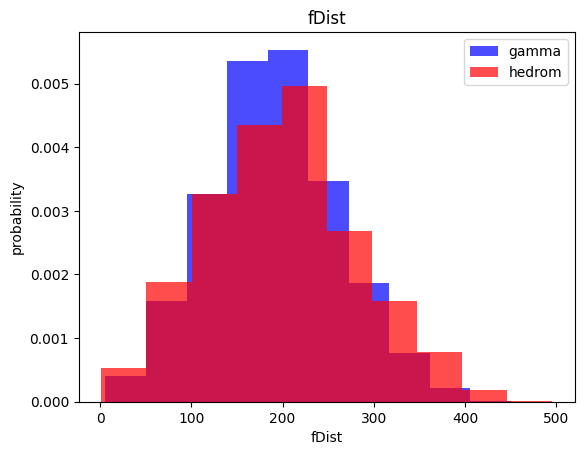

In [13]:
import matplotlib.pyplot as plt
for label in cols[:-1]:
     plt.hist(df[df['class']==1][label],color='blue',label='gamma',alpha=0.7,density=True)
     plt.hist(df[df['class']==0][label],color='red',label='hedrom',alpha=0.7,density=True)
     plt.title(label)
     plt.ylabel("probability")
     plt.xlabel(label)
     plt.legend()
     plt.show()


In [14]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
import numpy as np
X_raw=df.iloc[:,:-1].values
y_raw=df.iloc[:,-1].values
x_train_val, X_test, y_train_val, y_test = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=42
)

# Next, split that 80% into 60% train and 20% validation (0.25 of 0.80 is 0.20)
X_train, X_valid, y_train, y_valid = train_test_split(
    x_train_val, y_train_val, test_size=0.25, random_state=42
)
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fits AND transforms
X_valid_scaled = scaler.transform(X_valid)      # ONLY transforms (No leakage!)
X_test_scaled = scaler.transform(X_test)        # ONLY transforms (No leakage!)

# 4. Oversample ONLY the Training data
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_scaled, y_train)

# (Optional) Recombine into 2D arrays if your workflow requires the 'data' format
train_data = np.hstack((X_train_resampled, y_train_resampled.reshape(-1, 1)))
valid_data = np.hstack((X_valid_scaled, y_valid.reshape(-1, 1)))
test_data = np.hstack((X_test_scaled, y_test.reshape(-1, 1)))

In [15]:
#kNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
knn_model=KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train,y_train)
y_pred=knn_model.predict(X_test)
y_pred

array([0, 1, 1, ..., 1, 1, 0], shape=(3804,))

In [16]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.62      0.68      1344
           1       0.81      0.90      0.85      2460

    accuracy                           0.80      3804
   macro avg       0.79      0.76      0.77      3804
weighted avg       0.80      0.80      0.79      3804



# NAIVE BAYES

In [17]:
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()
nb_model=nb_model.fit(X_train,y_train)
y_pred=nb_model.predict(X_test)

In [18]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.71      0.38      0.50      1344
           1       0.73      0.92      0.81      2460

    accuracy                           0.73      3804
   macro avg       0.72      0.65      0.66      3804
weighted avg       0.72      0.73      0.70      3804



In [ ]:
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()
log_model=log_model.fit(X_train,y_train)
y_pred=log_model.predict(x_test)

c:\Users\esair\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\esair\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


ValueError: X has 4 features, but LogisticRegression is expecting 10 features as input.